In [91]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind
import pandas as pd
import seaborn as sns
import os
import sys
import pickle

In [92]:
data_directory = '/mnt/Data/Behavioural_Data/Bpod_data/'
experiment_name = 'D-AP5-Chronic-Infusion-SP120-137_Aug23_Analysis'
data_path = os.path.join(data_directory, experiment_name)

In [93]:
# list all the .pkl files in the current directory

pkl_files = [file for file in os.listdir(data_path) if file.endswith('.pkl')]

print(pkl_files)

['D-AP5-Chronic-Infusion-SP120-137_Aug23_dataframe.pkl']


In [94]:
# list pickle files in the data_path and load them as dictionaries
data_file = os.path.join(data_path, pkl_files[0])
with open(data_file, 'rb') as f:
    data = pickle.load(f)
print(data.keys())

Index(['AnimalID', 'ExperimentalGroup', 'SessionTime', 'FullSessionTime',
       'Protocol', 'Stimulation', 'Muscimol', 'RewardChange',
       'RewardChangeBlock', 'CenterPortDuration', 'Contingency',
       'RewardAmount', 'PunishDelay', 'Punish', 'BiasCorrection', 'TrialIndex',
       'TrialHighPerc', 'Outcomes', 'OptoStim', 'FirstPokeCorrect',
       'FirstPoke', 'TrialSide', 'TrialSequence', 'ResponseTime',
       'TrialStartTimestamp', 'CumulativePerformance', 'SwitchSide',
       'PreviousChoice', 'TrialEvents', 'TrialStates', 'FullGUI', 'SessionID',
       'ITIs', 'CumulativeTrialNumber', 'CumulativeTrialNumberByProtocol',
       'CurrentPastPerformance20', 'CurrentPastPerformance100',
       'NoOfCenterPokes', 'MiddleWaitTime', 'TrialInitiationTime', 'RightBias',
       'TrialsSpeed', 'PrevTrialSuccess'],
      dtype='object')


In [95]:
# convert the dictionary to a dataframe
df = pd.DataFrame(data)
df.head()

,AnimalID,ExperimentalGroup,SessionTime,FullSessionTime,Protocol,Stimulation,Muscimol,RewardChange,RewardChangeBlock,CenterPortDuration,...,CumulativeTrialNumber,CumulativeTrialNumberByProtocol,CurrentPastPerformance20,CurrentPastPerformance100,NoOfCenterPokes,MiddleWaitTime,TrialInitiationTime,RightBias,TrialsSpeed,PrevTrialSuccess
0,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,1,1.0,NaN,NaN,1,0.036407,290.7158,NaN,NaN,NaN
14,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,2,2.0,NaN,NaN,1,0.210900,NaN,NaN,NaN,0.0
17,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,3,3.0,NaN,NaN,1,0.349400,38.5954,NaN,1.313154,1.0
27,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,4,4.0,NaN,NaN,1,0.063000,49.1914,NaN,1.756277,1.0
34,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,5,5.0,NaN,NaN,1,0.058800,8.2032,NaN,1.751116,1.0


In [96]:
# df.info()
# if 'SP126' in df['AnimalID'].tolist():
#     print("'SP126' exists in the original dataframe.")
# else:
#     print("'SP126' does not exist in the original dataframe.")


### First saline session after chronic D-AP5 treatment: Task performance (%)

In [97]:
dates = df['FullSessionTime'].unique()
# print(dates)

In [98]:
# Provide AnimalIDs and dates for analysis
# refer to https://docs.google.com/spreadsheets/d/1ySelwJm3NSk8DC0BfwePGAgFHRN1nxvFOZ7CzhhhI9k/edit?usp=sharing
# D-AP5 and slaine dates according to animalIDs
# Note: For the D-AP5 group it needs to be manually checked as not all mice were stopped D-AP5 infusion once they reached 3000 trials

mice = ['SP120', 'SP121', 'SP122', 'SP124', 'SP126'] 
saline_dates = ['2023-06-07', '2023-06-09', '2023-06-08', '2023-06-05', '2023-06-05']
AP5_dates = ['2023-06-06', '2023-06-08', '2023-06-07', '2023-06-04', '2023-06-04']

# exctract data from saline and AP5 groups from df and save them as separate dataframes
# e.g. all rows with AnimalID == 'SP120' and FullSessionTime == '2023-06-07' will be saved in saline_df
# and all rows with AnimalID == 'SP120' and FullSessionTime == '2023-06-06' will be saved in AP5_df
# this will be done for all mice and dates in the saline_dates and AP5_dates lists
# the entries are corresponding to the same mouse and date in the saline_dates and AP5_dates lists

saline_df = pd.DataFrame()
AP5_df = pd.DataFrame()

for mouse, saline_date, AP5_date in zip(mice, saline_dates, AP5_dates):
    # print(mouse, saline_date, AP5_date) # check if the loop is working correctly
    # convert df['FullSessionTime'] to str to be able to compare it with the dates in the saline_dates and AP5_dates lists
    # take the first 10 characters of the string (yyyy-mm-dd)
    sessions = df['FullSessionTime'].astype(str).str[:10]
    saline_df = saline_df.append(df[(df['AnimalID'] == mouse) & (sessions == saline_date)])
    AP5_df = AP5_df.append(df[(df['AnimalID'] == mouse) & (sessions == AP5_date)])


## Some checks
# saline_df.head()
# AP5_df.head()
# print(saline_df['AnimalID'].unique())
# print(AP5_df['AnimalID'].unique())
# print(saline_df['FullSessionTime'].unique())
# print(AP5_df['FullSessionTime'].unique())


# append saline and AP5 dataframes with column Treatment. Assign 'Saline' to saline_df and 'D-AP5' to AP5_df

saline_df['Treatment'] = 'Saline'
AP5_df['Treatment'] = 'D-AP5'

# concatenate saline_df and AP5_df into one dataframe
# this will be used for plotting and statistical analysis

df_post_AP5 = pd.concat([saline_df, AP5_df])
# df_post_AP5.head()

In [99]:
def perf_window_calculator(firstpokecorrect, window):
    """
    Calculate the performance of the last X trials
    This is a function written by Hernando and used in APE paper (Greenstreet et al., 2022 for analysis)
    """
    perf_window = np.full(len(firstpokecorrect), np.nan)
    for i in range(len(perf_window)):
        if i < window:
            # For the first window-1 trials, dynamically adjust the window size
            current_window_size = i + 1
            perf_window[i] = np.nansum(firstpokecorrect[:i+1]) / current_window_size * 100
        else:
            perf_window[i] = np.nansum(firstpokecorrect[i - window + 1: i + 1]) / window * 100
    return perf_window

In [100]:
mice_to_remove = ['SP124']
# remove mice in the list mice_to_remove from the dataframe df_post_AP5
df_post_AP5 = df_post_AP5[~df_post_AP5['AnimalID'].isin(mice_to_remove)]


t-statistic:  0.27993030135967406
p-value:  0.7889313114122491


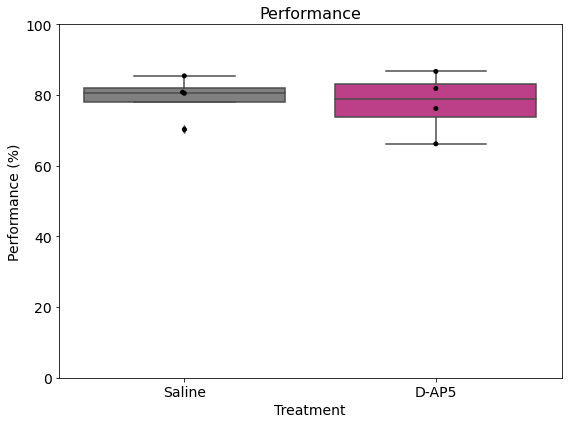

In [101]:

# plot Task Perfomrance in y-axis and grouped by Treatment in x-axis for df_post_AP5
# Perfomrance is calculated as the percentage of FirstPokeCorrect trials in the entire session
# calculate the percentage of firstpokecorrect trials in the entire session
# use formula df_post_AP5['FirstPokeCorrect'].sum() / len(df_post_AP5) * 100

# calculate the percentage of firstpokecorrect trials in the entire session

perf = df_post_AP5.groupby(['Treatment', 'AnimalID'])['FirstPokeCorrect'].sum() / df_post_AP5.groupby(['Treatment', 'AnimalID'])['FirstPokeCorrect'].count() * 100
perf = perf.reset_index()
perf.columns = ['Treatment', 'AnimalID', 'Performance']
# print(perf)

# perform student's t-test for saline and AP5 groups
# ttest_ind returns t-statistic and p-value
# print the t-statistic and p-value

t, p = ttest_ind(perf[perf['Treatment'] == 'Saline']['Performance'], perf[perf['Treatment'] == 'D-AP5']['Performance'])
print('t-statistic: ', t)
print('p-value: ', p)

# plot the performance the saline and AP5 groups

group_colors = {'Saline': '#808080', 'D-AP5': '#cf2c8b'}
group_order = ['Saline', 'D-AP5']

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x='Treatment', y='Performance', data=perf, palette=group_colors, order=group_order, ax=ax)
# plot swarmplot besides the boxplot, avoid overlapping points
sns.swarmplot(x='Treatment', y='Performance', data=perf, color='black', order=group_order, ax=ax)

ax.set_xlabel('Treatment', fontsize=14)
ax.set_ylabel('Performance (%)', fontsize=14)
ax.set_ylim(0, 100)
ax.tick_params(labelsize=14)
ax.set_title('Performance', fontsize=16)
plt.tight_layout()
plt.show()


### Here plot cumulative performance comparision between saline, D-AP5 and olanzapine infusion in expert mice performing COT task

In [43]:

if 'SP126' in df['AnimalID'].tolist():
    print("'SP126' exists in the original dataframe.")
else:
    print("'SP126' does not exist in the original dataframe.")


'SP126' exists in the original dataframe.


In [44]:
animals = ['SP120', 'SP121', 'SP122', 'SP124', 'SP126']
print(animals)

saline_dates = ['2023-07-21', '2023-07-25', '2023-07-31', '2023-08-01']
dap5_dates = ['2023-07-24', '2023-07-26']
olanzapine_dates = ['2023-08-03']

['SP120', 'SP121', 'SP122', 'SP124', 'SP126']


In [102]:
# exctract data from saline and AP5 groups from df and save them as separate dataframes
# e.g. all rows with AnimalID == 'SP120' and FullSessionTime == '2023-06-07' will be saved in saline_df

expert_saline_df = pd.DataFrame()
expert_dap5_df = pd.DataFrame()
expert_olanzapine_df = pd.DataFrame()

for animal, saline_date, dap5_date, olanzapine_date in zip(animals, saline_dates, dap5_dates, olanzapine_dates):
    # print(mouse, saline_date, AP5_date) # check if the loop is working correctly
    # convert df['FullSessionTime'] to str to be able to compare it with the dates in the saline_dates and AP5_dates lists
    # take the first 10 characters of the string (yyyy-mm-dd)
    sessions = df['FullSessionTime'].astype(str).str[:10]
    expert_saline_df = expert_saline_df.append(df[(df['AnimalID'] == animal) & (sessions == saline_date)])
    expert_dap5_df = expert_dap5_df.append(df[(df['AnimalID'] == animal) & (sessions == dap5_date)])
    expert_olanzapine_df = expert_olanzapine_df.append(df[(df['AnimalID'] == animal) & (sessions == olanzapine_date)])

# append saline and AP5 dataframes with column Treatment. Assign 'Saline' to saline_df, 'D-AP5' to AP5_df, and 'Olanzapine' to olanzapine_df

expert_saline_df['Treatment'] = 'Saline'
expert_dap5_df['Treatment'] = 'D-AP5'
expert_olanzapine_df['Treatment'] = 'Olanzapine'

# concatenate saline_df and AP5_df into one dataframe

expert_df = pd.concat([expert_saline_df, expert_dap5_df, expert_olanzapine_df])

# expert_df.head()


,AnimalID,ExperimentalGroup,SessionTime,FullSessionTime,Protocol,Stimulation,Muscimol,RewardChange,RewardChangeBlock,CenterPortDuration,...,CumulativeTrialNumberByProtocol,CurrentPastPerformance20,CurrentPastPerformance100,NoOfCenterPokes,MiddleWaitTime,TrialInitiationTime,RightBias,TrialsSpeed,PrevTrialSuccess,Treatment
2821,SP120,D-AP5,Jun07 14:17,2023-06-07 14:17:00,Auditory,NoStimulation,No,No,0,0.3,...,1979.0,NaN,NaN,1,0.454600,NaN,0.04,NaN,NaN,Saline
2822,SP120,D-AP5,Jun07 14:17,2023-06-07 14:17:00,Auditory,NoStimulation,No,No,0,0.3,...,1980.0,NaN,NaN,1,0.325200,NaN,0.06,NaN,0.0,Saline
2824,SP120,D-AP5,Jun07 14:17,2023-06-07 14:17:00,Auditory,NoStimulation,No,No,0,0.3,...,1981.0,NaN,NaN,9,0.338303,26.9038,0.06,2.797114,1.0,Saline
2828,SP120,D-AP5,Jun07 14:17,2023-06-07 14:17:00,Auditory,NoStimulation,No,No,0,0.3,...,1982.0,NaN,NaN,1,0.528400,NaN,0.04,2.877351,0.0,Saline
2829,SP120,D-AP5,Jun07 14:17,2023-06-07 14:17:00,Auditory,NoStimulation,No,No,0,0.3,...,1983.0,NaN,NaN,2,0.337500,3.0210,0.04,3.424530,1.0,Saline


In [103]:
mice_to_remove = ['SP124']
# remove mice in the list mice_to_remove from the dataframe df_post_AP5

expert_df = expert_df[~expert_df['AnimalID'].isin(mice_to_remove)]


Saline vs D-AP5
t-statistic:  nan
p-value:  nan
Saline vs Olanzapine
t-statistic:  nan
p-value:  nan
D-AP5 vs Olanzapine
t-statistic:  nan
p-value:  nan


/home/sthitapati/anaconda3/envs/behav/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3367: RuntimeWarning: Degrees of freedom <= 0 for slice
  **kwargs)
/home/sthitapati/anaconda3/envs/behav/lib/python3.7/site-packages/numpy/core/_methods.py:132: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


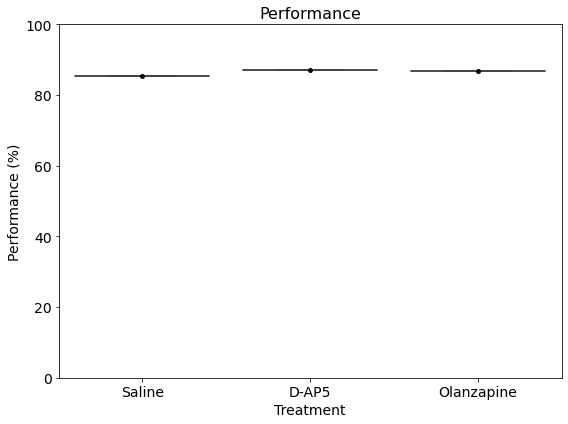

In [106]:
# plot Task Perfomrance in y-axis and grouped by Treatment in x-axis for expert_df
# Perfomrance is calculated as the percentage of FirstPokeCorrect trials in the entire session
# calculate the percentage of firstpokecorrect trials in the entire session
# use formula df_post_AP5['FirstPokeCorrect'].sum() / len(df_post_AP5) * 100

# calculate the percentage of firstpokecorrect trials in the entire session

perf = expert_df.groupby(['Treatment', 'AnimalID'])['FirstPokeCorrect'].sum() / expert_df.groupby(['Treatment', 'AnimalID'])['FirstPokeCorrect'].count() * 100
perf = perf.reset_index()
perf.columns = ['Treatment', 'AnimalID', 'Performance']

# perform student's t-test for saline, AP5, and olanzapine groups
# ttest_ind returns t-statistic and p-value
# print the t-statistic and p-value

print('Saline vs D-AP5')
t, p = ttest_ind(perf[perf['Treatment'] == 'Saline']['Performance'], perf[perf['Treatment'] == 'D-AP5']['Performance'])
print('t-statistic: ', t)
print('p-value: ', p)

print('Saline vs Olanzapine')
t, p = ttest_ind(perf[perf['Treatment'] == 'Saline']['Performance'], perf[perf['Treatment'] == 'Olanzapine']['Performance'])
print('t-statistic: ', t)
print('p-value: ', p)

print('D-AP5 vs Olanzapine')
t, p = ttest_ind(perf[perf['Treatment'] == 'D-AP5']['Performance'], perf[perf['Treatment'] == 'Olanzapine']['Performance'])
print('t-statistic: ', t)
print('p-value: ', p)

# plot the performance the saline,AP5, Olanzepine groups

group_colors = {'Saline': '#808080', 'D-AP5': '#cf2c8b', 'Olanzapine': '#2c7bb6'}

group_order = ['Saline', 'D-AP5', 'Olanzapine']

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x='Treatment', y='Performance', data=perf, palette=group_colors, order=group_order, ax=ax)
# plot swarmplot besides the boxplot, avoid overlapping points
sns.swarmplot(x='Treatment', y='Performance', data=perf, color='black', order=group_order, ax=ax)

ax.set_xlabel('Treatment', fontsize=14)

ax.set_ylabel('Performance (%)', fontsize=14)
ax.set_ylim(0, 100)
ax.tick_params(labelsize=14)
ax.set_title('Performance', fontsize=16)
plt.tight_layout()
plt.show()

In [30]:
def plot_performance_expert_mice(df, group_colors, alpha=1, exclude_animal_ids=[], window=100):
    """
    Plot performance by experimental group for expert mice.
    
    Parameters:
    - df: DataFrame with data.
    - group_colors: Dictionary specifying colors for each group.
    - alpha: Transparency for the swarmplot.
    """
    df = df.copy()
    # Filter for animals
    df = df[df['AnimalID'].isin(animals)]  # Create a copy to avoid warnings
    # Filter out rows with animal IDs to exclude
    if exclude_animal_ids:
        df = df[~df['AnimalID'].isin(exclude_animal_ids)]
    
    # Calculate the performance based on window size
    df['CumulativePerformance'] = perf_window_calculator(df['FirstPokeCorrect'], window)
    
    # Convert the 'FullSessionTime' column of df to string format
    df['FullSessionTime'] = pd.to_datetime(df['FullSessionTime']).dt.strftime('%Y-%m-%d')

    # Assign ExperimentalGroup based on dates
    conditions = [
        df['FullSessionTime'].isin(saline_dates),
        df['FullSessionTime'].isin(dap5_dates),
        df['FullSessionTime'].isin(olanzapine_dates)
    ]
    choices = ['Saline', 'D-AP5', 'Olanzapine']
    df['ExperimentalGroup'] = np.select(conditions, choices, default=np.nan)
    
    # Filter out any rows where ExperimentalGroup is 'nan' string or NaN
    df = df[df['ExperimentalGroup'].notna() & (df['ExperimentalGroup'] != 'nan')]
    
    # Debug step: Print unique values after filtering
    print("ExperimentalGroup values:", df['ExperimentalGroup'].unique())
    
    # Extract data for t-tests
    saline_performance = df[df['ExperimentalGroup'] == 'Saline']['CumulativePerformance']
    d_ap5_performance = df[df['ExperimentalGroup'] == 'D-AP5']['CumulativePerformance']
    olanzapine_performance = df[df['ExperimentalGroup'] == 'Olanzapine']['CumulativePerformance']

    # Remove NaN values
    saline_performance = saline_performance.dropna()
    d_ap5_performance = d_ap5_performance.dropna()
    olanzapine_performance = olanzapine_performance.dropna()

    # Perform t-tests
    t_stat_dap5_saline, p_value_dap5_saline = ttest_ind(d_ap5_performance, saline_performance, equal_var=False)
    t_stat_olanzapine_saline, p_value_olanzapine_saline = ttest_ind(olanzapine_performance, saline_performance, equal_var=False)
    print('D-AP5 vs Saline: t-statistic:', t_stat_dap5_saline, 'p-value:', p_value_dap5_saline)
    print('Olanzapine vs Saline: t-statistic:', t_stat_olanzapine_saline, 'p-value:', p_value_olanzapine_saline)
    
    # Plotting
    plt.figure(figsize=(6, 8))
    
    # Boxplot
    sns.boxplot(data=df, x='ExperimentalGroup', y='CumulativePerformance', palette=group_colors, order=['Saline', 'D-AP5', 'Olanzapine'], width=0.2)   

    # Adjust x-coordinates for swarmplot to plot beside the boxplot
    offset = 0.35
    swarm_adjust = lambda x: -offset if x == "Saline" else (0 if x == "D-AP5" else 1 + offset)
    df['SwarmX'] = df['ExperimentalGroup'].apply(swarm_adjust)
    print("SwarmX values:", df['SwarmX'].unique())
    # Swarmplot
    sns.swarmplot(data=df, x='SwarmX', y='CumulativePerformance', hue='ExperimentalGroup', palette=group_colors, dodge=True, size=3, alpha=alpha)

    # Adjust axes and legend
    ax = plt.gca()
    ax.axes.get_xaxis().set_visible(False)
    ax.set_xticks([-offset, 0, 1+offset])
    ax.set_xticklabels(['Saline', 'D-AP5', 'Olanzapine'])
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, loc='lower right')
    
    # Title, labels, and p-value
    plt.title(f"Task Performance in expert mice\nD-AP5 vs Saline p-value = {p_value_dap5_saline:.4f}\nOlanzapine vs Saline p-value = {p_value_olanzapine_saline:.4f}")
    plt.ylabel('Task Performance (%)')
    plt.xlabel('Experimental Group')
    plt.ylim(50, max(df['CumulativePerformance']) + 5)
    plt.tight_layout()
    plt.show()



ExperimentalGroup values: ['Saline' 'D-AP5' 'Olanzapine']
D-AP5 vs Saline: t-statistic: -5.937248035167389 p-value: 2.9982990741903395e-09
Olanzapine vs Saline: t-statistic: 6.435693767424344 p-value: 1.355545336274876e-10
SwarmX values: [-0.35  0.    1.35]


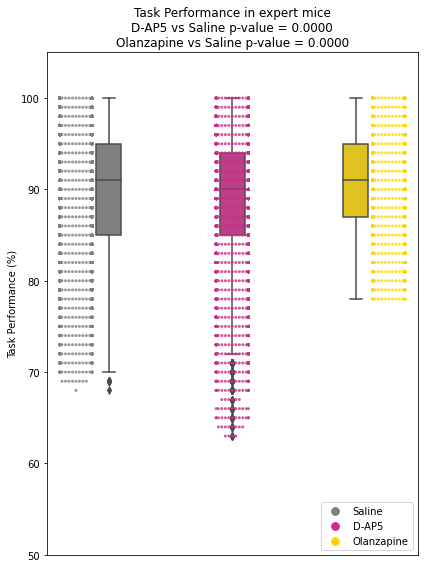

In [31]:
group_colors = {'Saline': '#808080', 'D-AP5': '#cf2c8b', 'Olanzapine': '#FFD700'}  
plot_performance_expert_mice(df, group_colors, alpha=0.8, exclude_animal_ids=[], window=100)

ExperimentalGroup values: ['Saline' 'D-AP5' 'Olanzapine']
D-AP5 vs Saline: t-statistic: -4.826789918306139 p-value: 1.4157771178571359e-06
Olanzapine vs Saline: t-statistic: 9.889690088262098 p-value: 8.673567172990026e-23
SwarmX values: [-0.35  0.    1.35]


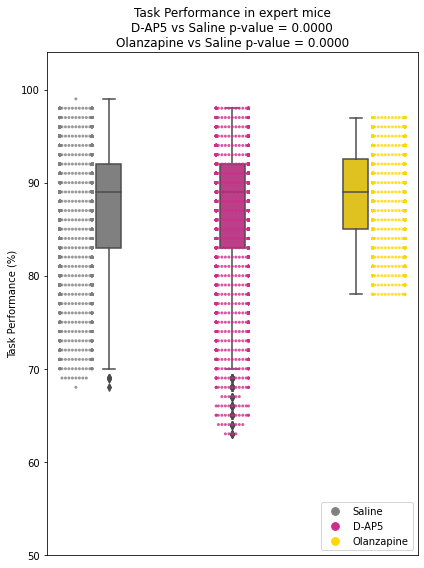

In [32]:
group_colors = {'Saline': '#808080', 'D-AP5': '#cf2c8b', 'Olanzapine': '#FFD700'}  
plot_performance_expert_mice(df, group_colors, alpha=0.8, exclude_animal_ids=['SP124', 'SP133'], window=100)